<a href="https://colab.research.google.com/github/briskicedteaa/CFTR-Variant-Explorer/blob/main/notebooks/CFTR_Variant_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_json("P13569.json")

count = df["features"].apply(lambda x: "begin" in x).sum()
count2 = df["features"].apply(lambda x: "wildType" in x).sum()
count3 = df["features"].apply(lambda x: "mutatedType" in x).sum()
count4 = df["features"].apply(lambda x: "consequenceType" in x).sum()
count5 = df["features"].apply(lambda x: "clinicalSignificances" in x).sum()
count6 = df["features"].apply(lambda x: "association" in x).sum()
print("Begin:", count,"wildType:", count2,"mutatedType:", count3,"consequenceType:", count4,"clinicalSignificances:", count5,"association:", count6)

Begin: 3664 wildType: 3664 mutatedType: 3216 consequenceType: 3664 clinicalSignificances: 2909 association: 2895


In [ ]:
variants = []

for feature in df["features"]:
  variants.append({
      "Position": int(feature["begin"]),
      "WildType": feature["wildType"],
      "MutatedType": feature.get("mutatedType"),
      "Consequence": feature["consequenceType"]
  })

variants_df = pd.DataFrame(variants)
variants_df["Position"].describe()
variants_df["Position"].nunique()
variants_df.head()

,Position,WildType,MutatedType,Consequence
0,1,M,None,initiator codon variant
1,1,M,I,missense
2,1,M,K,missense
3,1,M,R,missense
4,1,M,T,missense


In [ ]:
variants_df["Position"].value_counts().head(20)

,count
Position,
1098,8
508,8
137,8
311,7
14,7
17,7
1295,7
1023,7
1130,6


In [ ]:
variants_df["Consequence"].value_counts()

,count
Consequence,
missense,2809
frameshift,459
stop gained,316
inframe deletion,52
-,13
insertion,11
stop lost,3
initiator codon variant,1


In [ ]:
missense_df = variants_df[
    variants_df["Consequence"] == "missense"
].copy()

missense_df.shape

(2809, 4)

In [ ]:
position_variants = (
    variants_df.dropna(subset=["MutatedType"])
    .groupby("Position")["MutatedType"]
    .nunique()
    .sort_values(ascending=False)
)

position_variants.head(20)

,MutatedType
Position,
117,6
1098,6
192,6
317,6
579,6
530,6
506,6
508,6
1154,5


In [ ]:
!wget -q -O /usr/share/fonts/truetype/Humor-Sans.ttf https://github.com

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import logging
from matplotlib.colors import LinearSegmentedColormap

mpl.font_manager._load_fontmanager(try_read_cache=False)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

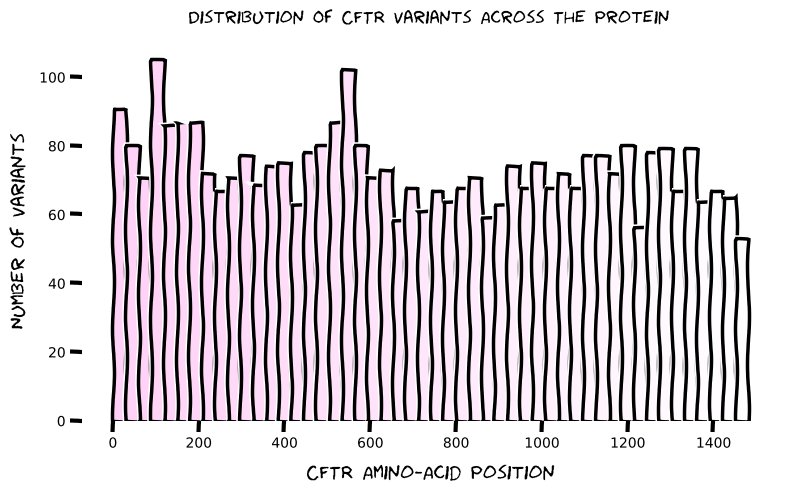

In [ ]:
textcolor = "#000000"
bgcolor = "#ffffff"
gridcolor = "#000000"

customgradient = LinearSegmentedColormap.from_list("pink_to_white", ["#ffd1f7", "#ffffff"])

mpl.rcParams['figure.facecolor'] = bgcolor
mpl.rcParams['axes.facecolor'] = bgcolor

with plt.xkcd():
  fig, ax = plt.subplots(figsize=(8, 5), facecolor=bgcolor)
  ax.set_facecolor(bgcolor)

  n, bins, patches = ax.hist(
      variants_df["Position"],
      bins=50,
      edgecolor='000000',
      alpha=1.0,
      linewidth=2.5,
      zorder=3
      )

  [patch.set_facecolor(customgradient(i / 50)) for i, patch in enumerate(patches)]

  plt.xlabel("CFTR Amino-Acid Position", weight='bold', labelpad=10, color=textcolor, fontname="Humor Sans")
  plt.ylabel("Number Of Variants", weight='bold', labelpad=10, color=textcolor, fontname="Humor Sans")
  plt.title("Distribution Of CFTR Variants Across The Protein", weight='bold', pad=15, color=textcolor, fontsize=13, fontname="Humor Sans")

  ax.tick_params(colors=textcolor, labelsize=10)
  ax.grid(axis='y', linestyle='-', alpha=1.0, color=gridcolor)

  for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
counts, edges, = pd.cut(
    variants_df["Position"],
    bins=50,
    retbins=True
)

bin_counts = counts.value_counts().sort_index()

m = bin_counts.reset_index()
hist_df = pd.DataFrame(m)

print(bin_counts)

Position
(-0.48, 30.6]        91
(30.6, 60.2]         80
(60.2, 89.8]         71
(89.8, 119.4]       105
(119.4, 149.0]       90
(149.0, 178.6]       83
(178.6, 208.2]       87
(208.2, 237.8]       72
(237.8, 267.4]       67
(267.4, 297.0]       75
(297.0, 326.6]       73
(326.6, 356.2]       69
(356.2, 385.8]       74
(385.8, 415.4]       75
(415.4, 445.0]       65
(445.0, 474.6]       76
(474.6, 504.2]       80
(504.2, 533.8]       87
(533.8, 563.4]      102
(563.4, 593.0]       81
(593.0, 622.6]       70
(622.6, 652.2]       73
(652.2, 681.8]       58
(681.8, 711.4]       68
(711.4, 741.0]       62
(741.0, 770.6]       66
(770.6, 800.2]       64
(800.2, 829.8]       68
(829.8, 859.4]       71
(859.4, 889.0]       61
(889.0, 918.6]       61
(918.6, 948.2]       74
(948.2, 977.8]       68
(977.8, 1007.4]      75
(1007.4, 1037.0]     69
(1037.0, 1066.6]     71
(1066.6, 1096.2]     68
(1096.2, 1125.8]     77
(1125.8, 1155.4]     77
(1155.4, 1185.0]     73
(1185.0, 1214.6]     79
(1214.6

In [ ]:
hist_df.columns = ["Position", "Variant_Count"]

hist_df.head()

,Position,Variant_Count
0,"(-0.48, 30.6]",91
1,"(30.6, 60.2]",80
2,"(60.2, 89.8]",71
3,"(89.8, 119.4]",105
4,"(119.4, 149.0]",90


In [ ]:
hist_df["Region"] = pd.cut(
    hist_df.index,
    bins=[-1, 16, 33, 50],
    labels=["N-terminal", "Middle", "C-terminal"]
)

hist_df

,Position,Variant_Count,Region
0,"(-0.48, 30.6]",91,N-terminal
1,"(30.6, 60.2]",80,N-terminal
2,"(60.2, 89.8]",71,N-terminal
3,"(89.8, 119.4]",105,N-terminal
4,"(119.4, 149.0]",90,N-terminal
5,"(149.0, 178.6]",83,N-terminal
6,"(178.6, 208.2]",87,N-terminal
7,"(208.2, 237.8]",72,N-terminal
8,"(237.8, 267.4]",67,N-terminal
9,"(267.4, 297.0]",75,N-terminal


In [ ]:
regional_avg = (
    hist_df.groupby("Region", observed = True)["Variant_Count"]
    .mean()
)

regional_stats = (
    hist_df.groupby("Region", observed = True)["Variant_Count"]
    .agg(["mean", "median", "min", "max"])
)

print("Averages:", regional_avg)
print("Stats:", regional_stats)

Averages: Region
N-terminal    78.411765
Middle        71.117647
C-terminal    70.125000
Name: Variant_Count, dtype: float64
Stats:                  mean  median  min  max
Region                                 
N-terminal  78.411765    75.0   65  105
Middle      71.117647    68.0   58  102
C-terminal  70.125000    70.0   53   79


In [ ]:
hist_df.sort_values(
    "Variant_Count",
    ascending=False
).head(10)

,Position,Variant_Count,Region
3,"(89.8, 119.4]",105,N-terminal
18,"(533.8, 563.4]",102,Middle
0,"(-0.48, 30.6]",91,N-terminal
4,"(119.4, 149.0]",90,N-terminal
17,"(504.2, 533.8]",87,Middle
6,"(178.6, 208.2]",87,N-terminal
5,"(149.0, 178.6]",83,N-terminal
19,"(563.4, 593.0]",81,Middle
1,"(30.6, 60.2]",80,N-terminal
16,"(474.6, 504.2]",80,N-terminal


In [ ]:
variants_df["Region"] = pd.cut(
    variants_df["Position"],
    bins=[0, 493, 986, 1480],
    labels=["N-terminal", "Middle", "C-terminal"]
)

variants_df

,Position,WildType,MutatedType,Consequence,Region
0,1,M,None,initiator codon variant,N-terminal
1,1,M,I,missense,N-terminal
2,1,M,K,missense,N-terminal
3,1,M,R,missense,N-terminal
4,1,M,T,missense,N-terminal
...,...,...,...,...,...
3659,1478,T,R,missense,C-terminal
3660,1479,R,K,missense,C-terminal
3661,1480,L,P,missense,C-terminal
3662,1481,*,Q,stop lost,NaN


In [ ]:
variant_region_counts = pd.crosstab(
    variants_df["Region"],
    variants_df["Consequence"]
)

variant_region_percent = pd.crosstab(
    variants_df["Region"],
    variants_df["Consequence"],
    normalize="index"
) * 100

print("Region Counts:", variant_region_counts)
print("Region Percent:", variant_region_percent.round(2))

Region Counts: Consequence  -  frameshift  inframe deletion  initiator codon variant  \
Region                                                                  
N-terminal   6         170                17                        1   
Middle       6         143                15                        0   
C-terminal   1         146                20                        0   

Consequence  insertion  missense  stop gained  stop lost  
Region                                                    
N-terminal           6       990          110          0  
Middle               1       921          107          0  
C-terminal           4       898           99          1  
Region Percent: Consequence     -  frameshift  inframe deletion  initiator codon variant  \
Region                                                                     
N-terminal   0.46       13.08              1.31                     0.08   
Middle       0.50       11.99              1.26                     0.00   
C-te

In [ ]:
substitution_counts = (
    variants_df[
        variants_df["Consequence"] == "missense"
    ]
    .groupby(["WildType", "MutatedType"])
    .size()
    .sort_values(ascending=False)
)

print(substitution_counts.head(20))

WildType  MutatedType
I         V              77
L         F              67
F         L              65
L         P              57
I         T              55
A         V              53
L         V              46
A         T              45
G         R              44
E         K              42
T         I              39
V         L              38
K         E              38
G         V              35
R         G              35
V         I              35
T         A              35
S         R              33
G         E              33
V         A              33
dtype: int64


In [ ]:
!pip install BioPython
from Bio import SeqIO

In [ ]:
import gzip

with gzip.open("uniprotkb_CFTR_2026_08_24.fasta.gz", "rt") as handle:
  records = list(SeqIO.parse(handle, "fasta"))

SeqIO.write(records, "CFTR_Homologs.fasta", "fasta")

15201

In [ ]:
for record in SeqIO.parse("CFTR_Homologs.fasta", "fasta"):
    print(f"Description: {record.description}")

Description: tr|A0A087Y0E6|A0A087Y0E6_POEFO Cystic fibrosis transmembrane conductance regulator OS=Poecilia formosa OX=48698 PE=3 SV=1
Description: tr|A0A091E3B6|A0A091E3B6_FUKDA Cystic fibrosis transmembrane conductance regulator OS=Fukomys damarensis OX=885580 GN=H920_00776 PE=3 SV=1
Description: tr|A0A0G2K3B1|A0A0G2K3B1_RAT Cystic fibrosis transmembrane conductance regulator OS=Rattus norvegicus OX=10116 GN=Cftr PE=1 SV=1
Description: sp|A0A0H2ZD27|CIF_PSEAB CFTR inhibitory factor OS=Pseudomonas aeruginosa (strain UCBPP-PA14) OX=208963 GN=cif PE=1 SV=1
Description: tr|A0A0U3J5G9|A0A0U3J5G9_ORYME Cystic fibrosis transmembrane conductance regulator OS=Oryzias melastigma OX=30732 PE=2 SV=1
Description: sp|A0A193CHJ5|PA2BC_CROTA Phospholipase A2 crotoxin basic subunit CBc OS=Crotalus tzabcan OX=1043006 PE=1 SV=1
Description: tr|A0A1L8HH97|A0A1L8HH97_XENLA Cystic fibrosis transmembrane conductance regulator OS=Xenopus laevis OX=8355 GN=abcc4.L PE=3 SV=1
Description: tr|A0A1S3MT62|A0A1S3M

In [ ]:
import pandas as pd

# Created df and added columns

df = pd.DataFrame({
    "ID": [record.id for record in records],
    "Description": [record.description for record in records],
    "Sequence": [str(record.seq) for record in records],
    "Length": [len(record.seq) for record in records],
})

# Filtering for only CFTR in description column

CFTR_df = df[
    df["Description"].str.contains(
        "Cystic fibrosis transmembrane conductance regulator",
        case=False,
        na=False
    )
].copy()

# Removed proteins containing "Fragment" in description

CFTR_df = CFTR_df[
    ~CFTR_df["Description"].str.contains(
        "Fragment",
        case=False,
        na=False
    )
].copy()

# Dropped duplicates

CFTR_df = CFTR_df.drop_duplicates(
    subset="Sequence",
    keep="first"

).copy()

print("Remaining Proteins:", len(CFTR_df))
print("Total Proteins:", len(df))
print("Duplicate sequences:", len(CFTR_df) - CFTR_df["Sequence"].nunique())
df.head()

Remaining Proteins: 1649
Total Proteins: 15201
Duplicate sequences: 0


,ID,Description,Sequence,Length
0,tr|A0A087Y0E6|A0A087Y0E6_POEFO,tr|A0A087Y0E6|A0A087Y0E6_POEFO Cystic fibrosis...,MEKVRKDGKKNPAATANILSKIFFWWLNPLFRIGYKRRLEEEDMYE...,1322
1,tr|A0A091E3B6|A0A091E3B6_FUKDA,tr|A0A091E3B6|A0A091E3B6_FUKDA Cystic fibrosis...,MYSVLPQDRSKYLGEELQGYWDREVLRAEKDTRKPSLTKAIIKCYW...,1311
2,tr|A0A0G2K3B1|A0A0G2K3B1_RAT,tr|A0A0G2K3B1|A0A0G2K3B1_RAT Cystic fibrosis t...,MDLEKLTGGGGGRKEEEREEKGEQSEGKDSVGEGREREEGGEREEG...,1665
3,sp|A0A0H2ZD27|CIF_PSEAB,sp|A0A0H2ZD27|CIF_PSEAB CFTR inhibitory factor...,MILDRLCRGLLAGIALTFSLGGFAAEEFPVPNGFESAYREVDGVKL...,319
4,tr|A0A0U3J5G9|A0A0U3J5G9_ORYME,tr|A0A0U3J5G9|A0A0U3J5G9_ORYME Cystic fibrosis...,MEKVGKNNPAATANIFSKIFFWWLNPLFRIGSKRRLDEDDMFEVLP...,1324


In [ ]:
CFTR_df[
    ["ID", "Description", "Length"]
].sort_values("Length").head(30)

# Dropped proteins below 1400 AA

CFTR_df = CFTR_df[
    CFTR_df["Length"] >= 1400
].copy()

print("Proteins remaining:", len(CFTR_df))
print("Below 1400 aa:", (CFTR_df["Length"] < 1400).sum())
print("1400 aa or longer:", (CFTR_df["Length"] >= 1400).sum())
CFTR_df["Length"].describe()

Proteins remaining: 1008
Below 1400 aa: 0
1400 aa or longer: 1008


,Length
count,1008.000000
mean,1474.126984
std,38.861168
min,1400.000000
25%,1454.000000
50%,1480.000000
75%,1488.000000
max,1750.000000


In [ ]:
from google.colab import files

with open("CFTR_Homologs.fasta", "w") as f:
    for _, row in CFTR_df.iterrows():
        f.write(f">{row['ID']}\n")
        f.write(f"{row['Sequence']}\n")

files.download("CFTR_Homologs.fasta")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from Bio import AlignIO

alignment = AlignIO.read(
    "clustalo-I20260824-221828-0411-59024886-p1m.aln-clustal_num",
    "clustal"
)

seq = str(alignment[0].seq)
print(len(seq))
print(seq.count("-"))
print(seq[:200])

4193
2477
------------------------------------------------------------------------------------------MDFCRRYKFLHI--------------------------------------------------------------------------LPR-------PAKRIVWSWRA---


In [ ]:
from collections import Counter

conservation = []

for i in range(alignment.get_alignment_length()):
  column = []

  for record in alignment:
    amino_acid = record.seq[i]
    if amino_acid != "-":
        column.append(amino_acid)


  if column:
    counts = Counter(column)
    most_common_count = counts.most_common(1)[0][1]
    score = most_common_count / len(column)

  else:
    score = None

  conservation.append(score)

conservation_df = pd.DataFrame({
    "Alignment_Position": range(1, len(conservation) + 1),
    "Conservation": conservation
})

print(conservation_df.head())
print(conservation_df["Conservation"].describe())

   Alignment_Position  Conservation
0                   1          1.00
1                   2          1.00
2                   3          1.00
3                   4          1.00
4                   5          0.75
count    4193.000000
mean        0.716346
std         0.277990
min         0.125000
25%         0.489989
50%         0.793177
75%         1.000000
max         1.000000
Name: Conservation, dtype: float64


In [ ]:
for record in alignment:
    if "HUMAN" in record.id.upper() or "HUMAN" in record.description.upper():
        print(record.id, record.description)

tr|A0A8V8TNN0|A0A8V8TNN0_HUMAN tr|A0A8V8TNN0|A0A8V8TNN0_HUMAN
tr|A0A8V8TNH2|A0A8V8TNH2_HUMAN tr|A0A8V8TNH2|A0A8V8TNH2_HUMAN
sp|P13569|CFTR_HUMAN sp|P13569|CFTR_HUMAN


In [ ]:
human_record = next(
    record for record in alignment
    if record.id == "sp|P13569|CFTR_HUMAN"
)

print("Human sequence length:", len(human_record.seq))
print("Human non-gap residues:", sum(aa != "-" for aa in human_record.seq))

Human sequence length: 4193
Human non-gap residues: 1480


In [ ]:
human_position = 0
mapping = []

for Alignment_Position, amino_acid in enumerate(human_record.seq, start=1):

  if amino_acid != "-":
    human_position += 1
    mapping.append({
        "Human_Position": human_position,
        "Alignment_Position": Alignment_Position
    })

position_map = pd.DataFrame(mapping)
print(position_map.head())
print(position_map.tail())
print("Mapped human positions:", len(position_map))

   Human_Position  Alignment_Position
0               1                 444
1               2                 445
2               3                 446
3               4                 447
4               5                 448
      Human_Position  Alignment_Position
1475            1476                3903
1476            1477                3904
1477            1478                3905
1478            1479                3906
1479            1480                3907
Mapped human positions: 1480


In [ ]:
position_conservation = position_map.merge(
    conservation_df,
    on="Alignment_Position",
    how="left"
)

print(position_conservation.head())
print(position_conservation[position_conservation["Human_Position"] == 508])

   Human_Position  Alignment_Position  Conservation
0               1                 444      0.809598
1               2                 445      0.763804
2               3                 446      0.417598
3               4                 447      0.740371
4               5                 448      0.773533
     Human_Position  Alignment_Position  Conservation
507             508                1645      0.996028


In [ ]:
variant_counts = (
    variants_df
    .groupby("Position")
    .size()
    .reset_index(name="Variant_Count")
)

variant_counts = variant_counts.rename(
    columns={"Position": "Human_Position"}
)

final_position_df = position_conservation.merge(
    variant_counts,
    on="Human_Position",
    how="left"
)

final_position_df["Variant_Count"] = (
    final_position_df["Variant_Count"]
    .fillna(0)
    .astype(int)
)

print(final_position_df.head())
print(final_position_df.shape)

   Human_Position  Alignment_Position  Conservation  Variant_Count
0               1                 444      0.809598              6
1               2                 445      0.763804              3
2               3                 446      0.417598              3
3               4                 447      0.740371              4
4               5                 448      0.773533              3
(1480, 4)


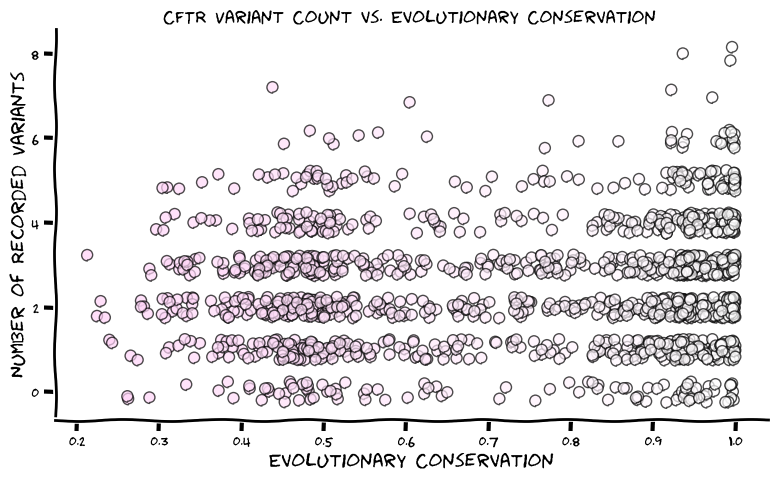

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

custom_pink_gradient = LinearSegmentedColormap.from_list(
    "pink_to_white",
    ["#ffd1f7", "#ffffff"]
)

np.random.seed(42)

final_position_df["Variant_Count_Jittered"] = (
    final_position_df["Variant_Count"]
    + np.random.uniform(-0.25, 0.25, len(final_position_df))
)

with plt.xkcd():
    mpl.rcParams["font.family"] = "Humor Sans"

    fig, ax = plt.subplots(figsize=(8, 5))

    scatter = ax.scatter(
        final_position_df["Conservation"],
        final_position_df["Variant_Count_Jittered"],
        c=final_position_df["Conservation"],
        cmap=custom_pink_gradient,
        edgecolor="#000000",
        linewidth=1,
        s=50,
        alpha=0.7,
        zorder=3
    )

    ax.set_xlabel(
        "Evolutionary Conservation",
        weight="bold",
        fontname="Humor Sans"
    )

    ax.set_ylabel(
        "Number of Recorded Variants",
        weight="bold",
        fontname="Humor Sans"
    )

    ax.set_title(
        "CFTR Variant Count vs. Evolutionary Conservation",
        weight="bold",
        fontsize=13,
        fontname="Humor Sans"
    )

    ax.tick_params(colors="#000000", labelsize=10)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname("Humor Sans")

    ax.grid(
        axis="y",
        linestyle="-",
        alpha=0.3,
        color="#000000"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.spines["left"].set_color("#000000")
    ax.spines["bottom"].set_color("#000000")
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    plt.tight_layout()
    plt.show()

In [ ]:
corr = final_position_df["Conservation"].corr(
    final_position_df["Variant_Count"]
)

print("Pearson correlation:", corr)

Pearson correlation: 0.10134511817654995


In [ ]:
final_position_df["Conservation_Group"] = pd.qcut(
    final_position_df["Conservation"],
    q=3,
    labels=["Low", "Medium", "High"]
)

summary = final_position_df.groupby(
    "Conservation_Group"
)["Variant_Count"].agg(
    ["mean", "median", "min", "max"]
)

print(summary)

                        mean  median  min  max
Conservation_Group                            
Low                 2.330629     2.0    0    7
Medium              2.397566     2.0    0    7
High                2.694332     3.0    0    8


/tmp/ipykernel_801/12425768.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = final_position_df.groupby(


In [44]:
region_conservation = (
    final_position_df
    .merge(
        variants_df[["Position", "Region"]].drop_duplicates(),
        left_on="Human_Position",
        right_on="Position",
        how="inner"
    )
     .groupby("Region")["Conservation"]
    .agg(["mean", "median", "min", "max"])
)

print(region_conservation)

                mean    median       min  max
Region                                       
N-terminal  0.757008  0.847619  0.239535  1.0
Middle      0.711997  0.775428  0.212581  1.0
C-terminal  0.768154  0.875752  0.234064  1.0


/tmp/ipykernel_801/3307041960.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Region")["Conservation"]


In [45]:
def cftr_domain(position):
    if 81 <= position <= 365:
        return "TMD1"
    elif 423 <= position <= 646:
        return "NBD1"
    elif 654 <= position <= 831:
        return "R domain"
    elif 859 <= position <= 1155:
        return "TMD2"
    elif 1210 <= position <= 1443:
        return "NBD2"
    else:
        return "Other"

final_position_df["CFTR_Domain"] = (
    final_position_df["Human_Position"].apply(cftr_domain)
)

print(
    final_position_df["CFTR_Domain"].value_counts()
    .sort_index()
)

CFTR_Domain
NBD1        224
NBD2        234
Other       262
R domain    178
TMD1        285
TMD2        297
Name: count, dtype: int64


In [46]:
domain_summary = (
    final_position_df
    .groupby("CFTR_Domain")
    .agg(
        Domain_Length=("Human_Position", "count"),
        Positions_With_Variants=(
            "Variant_Count",
            lambda x: (x > 0).sum()
        )
    )
)

domain_summary["Variant_Position_Percent"] = (
    domain_summary["Positions_With_Variants"]
    / domain_summary["Domain_Length"]
    * 100
)

print(domain_summary)

             Domain_Length  Positions_With_Variants  Variant_Position_Percent
CFTR_Domain                                                                  
NBD1                   224                      217                 96.875000
NBD2                   234                      220                 94.017094
Other                  262                      243                 92.748092
R domain               178                      163                 91.573034
TMD1                   285                      262                 91.929825
TMD2                   297                      278                 93.602694


In [47]:
variants_with_domains = variants_df.merge(
    final_position_df[
        ["Human_Position", "CFTR_Domain"]
    ],
    left_on="Position",
    right_on="Human_Position",
    how="left"
)

domain_consequence_counts = pd.crosstab(
    variants_with_domains["CFTR_Domain"],
    variants_with_domains["Consequence"]
)

print(domain_consequence_counts)

Consequence  -  frameshift  inframe deletion  initiator codon variant  \
CFTR_Domain                                                             
NBD1         1          68                11                        0   
NBD2         1          70                 3                        0   
Other        1          90                 7                        1   
R domain     4          51                 5                        0   
TMD1         4          96                12                        0   
TMD2         2          84                14                        0   

Consequence  insertion  missense  stop gained  stop lost  
CFTR_Domain                                               
NBD1                 0       479           47          0  
NBD2                 2       431           49          0  
Other                4       459           67          1  
R domain             0       286           47          0  
TMD1                 4       596           63          0  
TM

In [48]:
domain_consequence_percent = (
    pd.crosstab(
        variants_with_domains["CFTR_Domain"],
        variants_with_domains["Consequence"],
        normalize="index"
    ) * 100
)

print(domain_consequence_percent.round(2))

Consequence     -  frameshift  inframe deletion  initiator codon variant  \
CFTR_Domain                                                                
NBD1         0.17       11.22              1.82                     0.00   
NBD2         0.18       12.59              0.54                     0.00   
Other        0.16       14.29              1.11                     0.16   
R domain     1.02       12.98              1.27                     0.00   
TMD1         0.52       12.39              1.55                     0.00   
TMD2         0.28       11.97              1.99                     0.00   

Consequence  insertion  missense  stop gained  stop lost  
CFTR_Domain                                               
NBD1              0.00     79.04         7.76       0.00  
NBD2              0.36     77.52         8.81       0.00  
Other             0.63     72.86        10.63       0.16  
R domain          0.00     72.77        11.96       0.00  
TMD1              0.52     76.90     

In [49]:
domain_conservation = (
    final_position_df
    .groupby("CFTR_Domain")["Conservation"]
    .agg(["mean", "median", "min", "max"])
)

print(domain_conservation.round(3))

              mean  median    min    max
CFTR_Domain                             
NBD1         0.820   0.922  0.313  1.000
NBD2         0.791   0.893  0.304  1.000
Other        0.693   0.705  0.234  0.999
R domain     0.640   0.560  0.213  0.999
TMD1         0.768   0.894  0.369  1.000
TMD2         0.729   0.846  0.224  1.000
